# Part 1 - Baseline

In [1]:
import numpy as np
import pandas as pd

In [2]:
train = pd.read_csv('../input/titanic/train.csv').set_index('PassengerId') # training data

In [7]:
train.tail(10) # last 10 items

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


> How to make a dataset?

In [8]:
X_train = train.drop(['Survived'], axis=1)
Y_train = train['Survived'].astype(int)

> Try first model

In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
model = LogisticRegression()
model.fit(X_train, Y_train) # it fails

ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

> How to fix 'could not convert string to float: 'Braund, Mr. Owen Harris'?

In [12]:
X_train = X_train.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], axis=1)
X_train.head()

,Pclass,Age,SibSp,Parch,Fare
PassengerId,,,,,
1,3,22.0,1,0,7.2500
2,1,38.0,1,0,71.2833
3,3,26.0,0,0,7.9250
4,1,35.0,1,0,53.1000
5,3,35.0,0,0,8.0500


In [13]:
model = LogisticRegression()
model.fit(X_train, Y_train) # it fails again

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

> How to fix 'Input contains NaN, infinity or a value too large for dtype('float64')'?

In [14]:
X_train = X_train.fillna(0)

In [15]:
model = LogisticRegression()
model.fit(X_train, Y_train); # it works

> How to evaluate?

In [16]:
from sklearn.metrics import accuracy_score

In [17]:
Y_pred = model.predict(X_train)
accuracy_score(Y_train, Y_pred)

0.7048260381593715

> Is 0.7048 good? Try another model.

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_train)
accuracy_score(Y_train, Y_pred)

0.957351290684624

> Wow, much better. Try another model.

In [20]:
class TrickyClassifier():
    def fit(self, X, Y):
        self.data = dict(zip(X.index, Y))
    def predict(self, X):
        return X.index.map(lambda x: self.data.get(x, 0))

In [22]:
model = TrickyClassifier()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_train)
accuracy_score(Y_train, Y_pred)

1.0

> How to deal with cheaters?

In [23]:
test = pd.read_csv('../input/titanic/test.csv').set_index('PassengerId') # test data
test.tail()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


> How does it differ from the training set?

In [24]:
X_test = test.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], axis=1).fillna(0) # same transformations as train
X_test.head()

,Pclass,Age,SibSp,Parch,Fare
PassengerId,,,,,
892,3,34.5,0,0,7.8292
893,3,47.0,1,0,7.0000
894,2,62.0,0,0,9.6875
895,3,27.0,0,0,8.6625
896,3,22.0,1,1,12.2875


In [25]:
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

In [27]:
def make_submission(X_test, Y_pred, title):
    submission = pd.DataFrame({
        "PassengerId": X_test.index,
        "Survived": Y_pred 
    })    
    submission.to_csv(title, index=False) 

make_submission(X_test, Y_pred, 'dt1.csv') # it scores 0.61004

> How to improve the score?

# Part 2 - Features

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

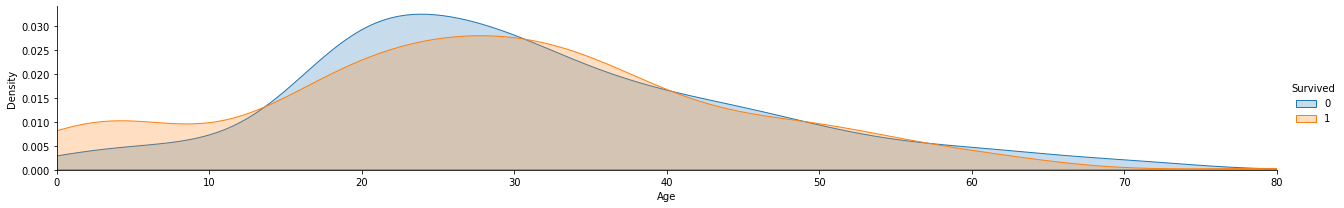

In [30]:
a = sns.FacetGrid(train, hue = 'Survived', aspect=6)
a.map(sns.kdeplot, 'Age', shade=True)
a.set(xlim=(0 , train['Age'].max()))
a.add_legend();

> Which guys had more chances?

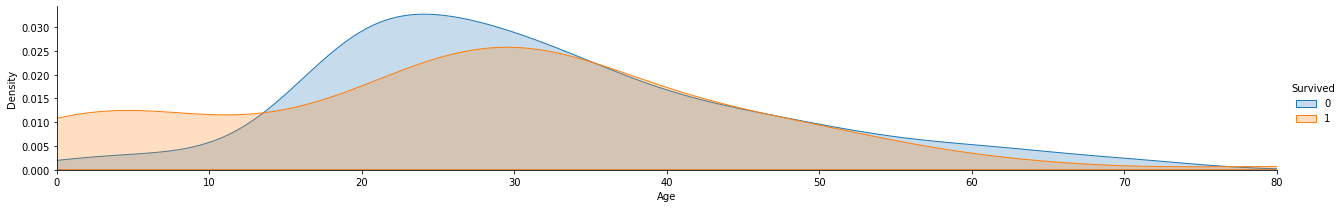

In [29]:
a = sns.FacetGrid(train[train.Sex=='male'], hue = 'Survived', aspect=6)
a.map(sns.kdeplot, 'Age', shade=True)
a.set(xlim=(0 , train['Age'].max()))
a.add_legend();

> Which girls had more chances?

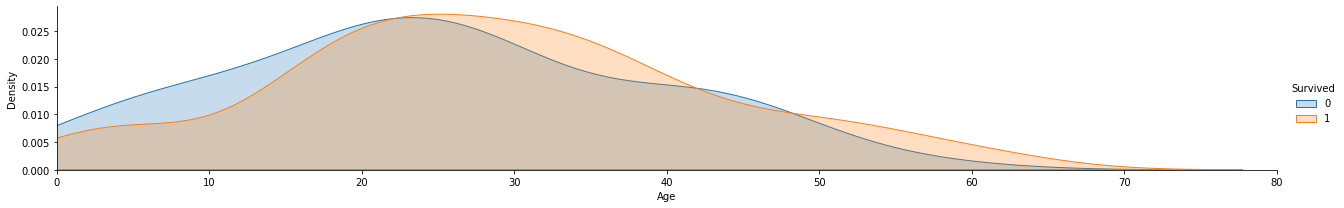

In [31]:
a = sns.FacetGrid(train[train.Sex=='female'], hue = 'Survived', aspect=6)
a.map(sns.kdeplot, 'Age', shade=True)
a.set(xlim=(0 , train['Age'].max()))
a.add_legend();

> What about the rich?

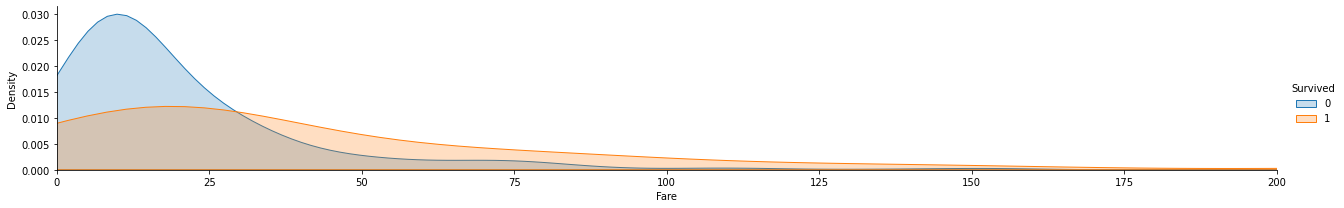

In [32]:
a = sns.FacetGrid(train, hue = 'Survived', aspect=6)
a.map(sns.kdeplot, 'Fare', shade=True)
a.set(xlim=(0 , 200))
a.add_legend();

> Which port has the most people?

In [33]:
train[['Embarked', 'Survived']].groupby(['Embarked']).agg(['count','mean'])

Survived          
            count      mean
Embarked                   
C             168  0.553571
Q              77  0.389610
S             644  0.336957

## NaN values

In [35]:
data = pd.concat([train, test])
train_size = train.shape[0] # 891
data = data.drop(['Survived','Ticket', 'Cabin'], axis=1)
data[train_size-3:train_size+3]

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S
890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C
891,3,"Dooley, Mr. Patrick",male,32.0,0,0,7.7500,Q
892,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,Q


> How to fill_na Age?

In [36]:
import math

In [37]:
avg_age = round(data['Age'].mean(), 2)
data['Age'] = data['Age'].fillna(avg_age)
avg_age

29.88

> Fare?

In [38]:
avg_fare = round(data['Fare'].mean(), 4)
data['Fare'] = data['Fare'].fillna(avg_fare)
avg_fare

33.2955

> Embarked?

In [39]:
data['Embarked'] = data['Embarked'].fillna('S') # most frequent

In [40]:
data[data.isna().any(axis=1)]

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,


## Feature engineering

> Is name useful?

In [42]:
data.head(30)

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.00,1,0,7.2500,S
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,71.2833,C
3,3,"Heikkinen, Miss. Laina",female,26.00,0,0,7.9250,S
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,53.1000,S
5,3,"Allen, Mr. William Henry",male,35.00,0,0,8.0500,S
6,3,"Moran, Mr. James",male,29.88,0,0,8.4583,Q
7,1,"McCarthy, Mr. Timothy J",male,54.00,0,0,51.8625,S
8,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,21.0750,S
9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00,0,2,11.1333,S


In [43]:
data['Title'] = data['Name'].str.extract('([A-Za-z]+)\.', expand=False)
data['Title'] = data['Title'].replace(['Don', 'Capt', 'Col', 'Major', 'Sir', 'Jonkheer', 'Rev', 'Dr'], 'Honored')
data['Title'] = data['Title'].replace(['Lady', 'Dona', 'Mme', 'Countess'], 'Mrs')
data['Title'] = data['Title'].replace(['Mlle', 'Ms'], 'Miss')
data = data.drop(['Name'], axis=1)
data.groupby(['Title'])['Title'].agg(['count'])

,count
Title,
Honored,26
Master,61
Miss,264
Mr,757
Mrs,201


> What about family?

In [69]:
data['IsAlone'] = (data['SibSp'] + data['Parch'] == 0).astype(int)
data.groupby(['IsAlone'])['IsAlone'].agg(['count'])

,count
IsAlone,
0,519
1,790


In [70]:
data['FamilySize'] = (data['SibSp'] + data['Parch']).astype(int)
data.groupby(['FamilySize'])['FamilySize'].agg(['count'])

,count
FamilySize,
0,790
1,235
2,159
3,43
4,22
5,25
6,16
7,8
10,11


> Singles had more chances?

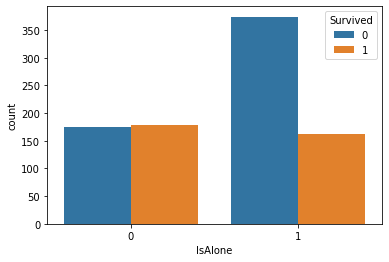

In [71]:
temp = data[:train_size].join(train['Survived'].astype(int)) # we should take only training part of data
sns.countplot(x="IsAlone", hue="Survived", data=temp);

> Does a big family help?

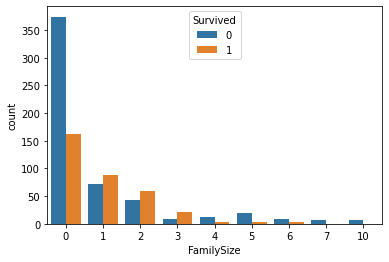

In [73]:
sns.countplot(x="FamilySize", hue="Survived", data=temp);

## Catogorical features

In [74]:
from sklearn.preprocessing import LabelEncoder

In [75]:
data['SexCode'] = LabelEncoder().fit_transform(data['Sex'])
data['TitleCode'] = LabelEncoder().fit_transform(data['Title'])
data['EmbarkedCode'] = LabelEncoder().fit_transform(data['Embarked'])
data = data.drop(['Sex', 'Title', 'Embarked'], axis=1)
data.head()

,Pclass,Age,SibSp,Parch,Fare,IsAlone,FamilySize,SexCode,TitleCode,EmbarkedCode
PassengerId,,,,,,,,,,
1,3,22.0,1,0,7.2500,0,1,1,3,2
2,1,38.0,1,0,71.2833,0,1,0,4,0
3,3,26.0,0,0,7.9250,1,0,0,2,2
4,1,35.0,1,0,53.1000,0,1,0,4,2
5,3,35.0,0,0,8.0500,1,0,1,3,2


## Second baseline

In [76]:
X_train = data[:train_size]
Y_train = train['Survived'].astype(int)
X_test = data[train_size:]

In [77]:
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
model.score(X_train, Y_train)

0.9842873176206509

In [78]:
make_submission(X_test, Y_pred, 'dt2.csv') # it scores 0.73205 (dt1 - 0.61004)

> Why is the actual value so different from the predicted value?

## Validation set

In [79]:
from sklearn import model_selection

In [80]:
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
print(model.score(X_train, Y_train))

scores = model_selection.cross_val_score(model, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on DecisionTreeClassifier: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

0.9842873176206509
[0.74860335 0.75280899 0.81460674 0.74157303 0.79775281]
Kfold on DecisionTreeClassifier: 0.7711 (+/- 0.0294)


In [81]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
print(model.score(X_train, Y_train))

scores = model_selection.cross_val_score(model, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on LogisticRegression: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

0.8069584736251403
[0.77653631 0.79213483 0.78651685 0.79213483 0.81460674]
Kfold on LogisticRegression: 0.7924 (+/- 0.0125)


> Which model is better?

In [82]:
Y_pred = model.predict(X_test) # LogisticRegression
make_submission(X_test, Y_pred, 'lr1.csv') # it scores 0.76555

# Part 3 - Algorithms

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron, SGDClassifier, LogisticRegression

In [84]:
linear_svc = SVC(C=0.07)
linear_svc.fit(X_train, Y_train)
print(linear_svc.score(X_train, Y_train))

scores = model_selection.cross_val_score(linear_svc, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on SVC: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

0.6778900112233446
[0.59776536 0.71348315 0.66292135 0.68539326 0.67977528]
Kfold on SVC: 0.6679 (+/- 0.0386)


In [85]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, Y_train)
print(knn.score(X_train, Y_train))

scores = model_selection.cross_val_score(knn, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on KNeighborsClassifier: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

0.7744107744107744
[0.63687151 0.66853933 0.71348315 0.76404494 0.7247191 ]
Kfold on KNeighborsClassifier: 0.7015 (+/- 0.0444)


In [86]:
gsn = GaussianNB()
gsn.fit(X_train, Y_train)
print(gsn.score(X_train, Y_train))

scores = model_selection.cross_val_score(gsn, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on GaussianNB: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

0.7946127946127947
[0.73743017 0.78651685 0.79775281 0.80337079 0.82022472]
Kfold on GaussianNB: 0.7891 (+/- 0.0280)


In [87]:
ptn = Perceptron()
ptn.fit(X_train, Y_train)
print(ptn.score(X_train, Y_train))

scores = model_selection.cross_val_score(ptn, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on Perceptron: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

0.3984287317620651
[0.55865922 0.66292135 0.65730337 0.75842697 0.7752809 ]
Kfold on Perceptron: 0.6825 (+/- 0.0784)


In [88]:
abc_params = {
    'n_estimators': 700,
}

abc = AdaBoostClassifier(**abc_params)
abc.fit(X_train, Y_train)
print(abc.score(X_train, Y_train))

scores = model_selection.cross_val_score(abc, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on AdaBoostClassifier: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

0.877665544332211
[0.80446927 0.79775281 0.85393258 0.83146067 0.8258427 ]
Kfold on AdaBoostClassifier: 0.8227 (+/- 0.0201)


In [89]:
rf_params = {
    'n_estimators': 700,
    'max_depth': 5,
    'min_samples_split': 10,
    'min_samples_leaf': 1,
    'max_features':'auto',
    'oob_score':True,
}

random_forest = RandomForestClassifier(**rf_params)
random_forest.fit(X_train, Y_train)
print(random_forest.score(X_train, Y_train))

scores = model_selection.cross_val_score(random_forest, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on RandomForestClassifier: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

Y_pred = random_forest.predict(X_test)
make_submission(X_test, Y_pred, 'RandomForestClassifier.csv') # 0.78229

0.8473625140291807
[0.8547486  0.81460674 0.8258427  0.80337079 0.85393258]
Kfold on RandomForestClassifier: 0.8305 (+/- 0.0207)


In [90]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train, Y_train)
print(gbc.score(X_train, Y_train))

scores = model_selection.cross_val_score(gbc, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on GradientBoostingClassifier: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

Y_pred = gbc.predict(X_test)
make_submission(X_test, Y_pred, 'GradientBoostingClassifier.csv') # 0.78229

0.9034792368125701
[0.82122905 0.8258427  0.85955056 0.82022472 0.85393258]
Kfold on GradientBoostingClassifier: 0.8362 (+/- 0.0170)


In [93]:
import xgboost as xgb

In [97]:
xgb_params = {
    'learning_rate': 0.5,
    'max_depth': 3   
}

xbc = xgb.XGBClassifier(**xgb_params)
xbc.fit(X_train, Y_train)
print(xbc.score(X_train, Y_train))

scores = model_selection.cross_val_score(xbc, X_train, Y_train, cv=5, scoring='accuracy')
print(scores)
print("Kfold on XGBClassifier: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std()))

Y_pred = xbc.predict(X_test)
make_submission(X_test, Y_pred, 'XGBClassifier.csv') # 0.75598

0.9371492704826038
[0.83240223 0.83146067 0.88764045 0.81460674 0.84831461]
Kfold on XGBClassifier: 0.8429 (+/- 0.0248)


> How to improve the score?